# Incident Response: Tier 0 Domain Compromise (Pirate Hunt)

## 1. Executive Summary
Our threat hunting team detected an advanced Active Directory compromise targeting our Tier 0 infrastructure (Domain Controllers). The adversary executed a multi-stage attack leveraging legacy group permissions, NTLM Coercion, and ultimately **Kerberos Constrained Delegation (KCD) Hijacking** via **Service Principal Name (SPN) Manipulation**.

### Hunt Hypothesis & Behavioral Outliers
* **Hypothesis:** Adversaries bypassing standard EDR will generate anomalous directory replication or modification events, specifically targeting delegation attributes and SPNs originating from non-system endpoints.
* **Outliers Detected:** A delegated user account (`a.white_adm`) was observed removing and immediately reallocating a `servicePrincipalName` across two distinct machine accounts (`WEB01&#36;` to `DC01&#36;`), indicating an active KCD hijacking attempt.
* **Toxic Combinations Exploited:** `Pre-Windows 2000 Compatible Access` + Accounts with `WriteSPN` + Kerberos Constrained Delegation.

---

## 2. Summary of Attack Chain

| Step | User / Access | Technique Used | Result |
| :---: | :--- | :--- | :--- |
| 1 | N/A (External) | **Active Directory Enumeration** | Identified `MS01&#36;` as a member of **Pre-Windows 2000 Compatible Access** via `adscan` and `bloodhound-python`. |
| 2 | MS01&#36; | **AS-REQ (Default Machine Password)** | Requested a TGT for `MS01&#36;` using the machine name (`ms01`) as its password. |
| 3 | MS01&#36; | **LDAP Read (gMSA Extraction)** | Dumped `gMSA_ADFS_prod&#36;` NT hash by reading `msDS-ManagedPassword` through legacy group privileges. |
| 4 | gMSA_ADFS_prod&#36; | **Pass-the-Hash (WinRM)** | Authenticated to `DC01` using **Evil-WinRM**, establishing initial foothold. |
| 5 | gMSA_ADFS_prod&#36; | **Network Pivoting** | Created Layer-3 tunnel to internal subnet `192.168.100.0/24` using **Ligolo-ng**. |
| 6 | gMSA_ADFS_prod&#36; | **NTLM Coercion & Relaying** | Coerced `WEB01&#36;` authentication and relayed NTLM to `DC01` over LDAPS to perform RBCD attack. |
| 7 | gMSA_ADFS_prod&#36; | **RBCD & S4U Impersonation** | Injected rogue computer `VYSHKGDW&#36;` and forged service ticket for `Administrator` on `WEB01`. |
| 8 | Administrator (WEB01) | **Lateral Movement (User Flag)** | Used **Impacket** `psexec.py` to gain admin shell on `WEB01` and retrieve **user.txt**. |
| 9 | Administrator (WEB01) | **Credential Harvesting** | Dumped local secrets to recover plaintext password for `a.white`. |
| 10 | a.white | **ACL Tiering Violation** | Abused `ForceChangePassword` rights to overwrite password for `a.white_adm`. |
| 11 | a.white_adm | **SPN Injection** | Removed `HTTP` SPN from `WEB01&#36;` and injected into `DC01&#36;`, hijacking constrained delegation path. |
| 12 | a.white_adm | **Kerberos Constrained Delegation (S4U)** | Requested forged `CIFS` ticket to `DC01` impersonating Domain Admin. |
| 13 | Administrator (DC01) | **Pass-the-Ticket (Root Flag)** | Used forged ticket with `psexec.py` to access `DC01` and retrieve **root.txt**. |

## Logs Onboarding

Logs Added: [Pulled Logs from compromised Environment](https://raw.githubusercontent.com/0x0z0n/Research/refs/heads/main/posts/Pirate/Loot_20260302_0735.zip "Results")

Raw Logs: [Plaso Telemetry_to CSV Evidence_collected](https://raw.githubusercontent.com/0x0z0n/Research/refs/heads/main/posts/Pirate/Evidence/detections_data.csv "Results")

Logs Processing : [Data_Wrangling.py](https://raw.githubusercontent.com/0x0z0n/Research/refs/heads/main/posts/Pirate/Evidence/Data_Wrangle.py "Results")

Normalised Logs Added: [Clean_Logs](https://raw.githubusercontent.com/0x0z0n/Research/refs/heads/main/posts/Pirate/Evidence/normalized_soc_data.csv "Results")


### 1. Create the Normalized Table
Run this command to create the new `NormalizedSecurityEvents` table. Notice how clean the schema is now—this is a true SIEM-ready table structure.

```kusto
.create table NormalizedSecurityEvents (
    ['datetime']: datetime,
    display_name: string,
    EventID: string,
    AccountName: string,
    LogonType: string,
    SourceIP: string,
    ServiceName: string,
    ModifiedSPN: string,
    message: string
)
```

![Data_ingestion](htb_Pirate_data_lake_table_schema.png)

### 2. Create the CSV Ingestion Mapping
This explicitly tells ADX which column in your CSV belongs to which field in the new table.

```kusto
.create-or-alter table NormalizedSecurityEvents ingestion csv mapping 'NormalizedEvents_CSV_Mapping' 
'['
'    {"column":"datetime", "Properties":{"Ordinal":"0"}, "datatype":"datetime"},'
'    {"column":"display_name", "Properties":{"Ordinal":"1"}, "datatype":"string"},'
'    {"column":"EventID", "Properties":{"Ordinal":"2"}, "datatype":"string"},'
'    {"column":"AccountName", "Properties":{"Ordinal":"3"}, "datatype":"string"},'
'    {"column":"LogonType", "Properties":{"Ordinal":"4"}, "datatype":"string"},'
'    {"column":"SourceIP", "Properties":{"Ordinal":"5"}, "datatype":"string"},'
'    {"column":"ServiceName", "Properties":{"Ordinal":"6"}, "datatype":"string"},'
'    {"column":"ModifiedSPN", "Properties":{"Ordinal":"7"}, "datatype":"string"},'
'    {"column":"message", "Properties":{"Ordinal":"8"}, "datatype":"string"}'
']'
```

![Data_ingestion](htb_Pirate_data_lake_table_Ingestion.png)

### 3. Ingest the Data
If you are uploading the file through the **ADX Web UI**:
1. Right-click your database -> **Get Data** -> **Local file**.
2. **Destination tab:** Select **Existing table** and pick `NormalizedSecurityEvents`.
3. **Source tab:** Upload your `normalized_soc_data.csv` file.
4. **Schema tab:** Ensure **Ignore the first record** is toggled `ON` (to skip the header). 
5. Under the mapping dropdown, select **Existing mapping** and choose `NormalizedEvents_CSV_Mapping`.
6. Click **Finish**.

![Data_ingestion](htb_Pirate_data_lake_table_map.png)

*Or, if doing this programmatically via blob storage:*

```kusto
.ingest async into table NormalizedSecurityEvents ('https://<blob path to upload>') 
with (
    format='csv',
    ignoreFirstRecord=true, 
    ingestionMappingReference='NormalizedEvents_CSV_Mapping',
    ingestionMappingType='csv'
)
```

## Initial Triage

#### Event ID 1102 (Audit log cleared) or 104 (System log cleared)

There is almost never a legitimate business reason for a standard user or even a standard sysadmin to manually clear the Windows Security or System event logs. This is a classic defense evasion tactic used immediately after a box is compromised.

```KQL
NormalizedSecurityEvents
// Filter for log clearing event IDs
| where EventID in ("1102", "104")
// We don't need the whole message for triage, just who did it and when
| project ['datetime'], EventID, AccountName, display_name
| order by ['datetime'] desc
```

![Triage](htb_Pirate_L1_Event_logs_Audit_cleared.png)

#### Brute Force & Password Spraying

![Triage](htb_Pirate_L1_Event_failed_logon_attempts.png)

#### Reconstructing the Attack Timeline

Need to see everything that account did, in chronological order, to understand the scope of the breach.

```
let TargetAccount = "Administrator"; 
NormalizedSecurityEvents
| where AccountName =~ TargetAccount
// Filter for high-impact events: Logons, Privileges, SPN Mods, Ticket Requests, Log Clears
| where EventID in ("4624", "4672", "5136", "4769", "1102")
| project ['datetime'], EventID, LogonType, SourceIP, ServiceName, ModifiedSPN, message
// Sort ASCENDING so you can read the attacker's steps in chronological order
| order by ['datetime'] asc
```

Log Evidence : [Evidence](https://raw.githubusercontent.com/0x0z0n/Research/refs/heads/main/posts/Pirate/Evidence/Timeline_L2_triage_attack.csv "Results")


![Triage](htb_Pirate_L2_Triage_Attack.png)

#### Hunting for SPN Hijacking

```
NormalizedSecurityEvents
| where EventID == "5136"
| extend Attribute = extract(@"LDAP Display Name:(?:\\t|\\s)+([^\\]+)", 1, message)
| extend NewValue = extract(@"Value:(?:\\t|\\s)+([^\\]+)", 1, message)
// Focus on SPN changes
| where Attribute =~ "servicePrincipalName"
| project ['datetime'], AccountName, Attribute, NewValue, ModifiedSPN
| order by ['datetime'] desc
```

![Triage](htb_Pirate_SPN_mod.png)
![Triage](htb_Pirate_SPN_mod2.png)



## Attack Path 

Assume Breach Scenario:

CTI Identified Leaked credentials for the following account pentest / p3nt3st2025!&


![Pirate](htb_Pirate_blood_chain.png)

In [26]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

### Suppress warnings for cleaner presentation

In [27]:
import warnings
warnings.filterwarnings('ignore')

print("[*] Initializing Forensic Environment & Loading Plaso Telemetry...")

[*] Initializing Forensic Environment & Loading Plaso Telemetry...


### Load the dataset

In [28]:
df = pd.read_csv('detections_data.csv', low_memory=False)

### Extract Event IDs robustly from the Plaso message string

In [29]:
df['event_id'] = pd.to_numeric(df['message'].str.extract(r'^\[(\d+)\s*/')[0], errors='coerce').fillna(0).astype(int)

In [30]:
print(f"[+] Successfully loaded {len(df)} total events.")

[+] Successfully loaded 65663 total events.


## 3. Forensic Evidence: Initial Access & NTLM Coercion (Steps 4 - 6)
To prove the beginning of the attack chain, we hunted for the compromised Group Managed Service Account (`gMSA_ADFS_prod$`). The logs revealed anomalous WinRM tunneling from an external pivot IP (`192.168.100.2`), followed immediately by rogue DNS node creation, setting the stage for NTLM coercion.

In [31]:
print("[*] Correlating Initial Access & DNS Spoofing Indicators...")

[*] Correlating Initial Access & DNS Spoofing Indicators...


### 1. Hunt for Step 4 & 5: gMSA_ADFS_prod$ Anomalous WinRM Connections (Event 2947)

In [32]:
gmsa_auth = df[(df['event_id'] == 2947) & (df['message'].str.contains('gMSA_ADFS_prod', case=False, na=False))].copy()

In [33]:
if not gmsa_auth.empty:
    gmsa_auth['Attacker_Account'] = gmsa_auth['message'].str.extract(r'CN=(gMSA_ADFS_prod)')
    gmsa_auth['Source_IP_Port'] = gmsa_auth['message'].str.extract(r'(\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}:\d+)')
    
    print("\n[!] EVIDENCE (Step 4 & 5): Pass-the-Hash & WinRM Tunnel Detected")
    display(gmsa_auth[['datetime', 'event_id', 'Attacker_Account', 'Source_IP_Port']].head(1).style.set_properties(**{'background-color': '#fff3f3', 'border-color': 'gray'}))


[!] EVIDENCE (Step 4 & 5): Pass-the-Hash & WinRM Tunnel Detected


,datetime,event_id,Attacker_Account,Source_IP_Port
8025,2025-06-09T17:48:41.954478+00:00,2947,gMSA_ADFS_prod,192.168.100.2:49769


### 2. Hunt for Step 6: Rogue DNS Node Creation for NTLM Coercion (Event 5136)

In [34]:
gmsa_dns = df[(df['event_id'] == 5136) & 
              (df['message'].str.contains('gMSA_ADFS_prod', na=False, case=False)) &
              (df['message'].str.contains('dnsNode', na=False, case=False))].copy()

In [35]:
if not gmsa_dns.empty:
    gmsa_dns['Attacker_Account'] = gmsa_dns['message'].str.extract(r'Account Name:\\t\\t(.*?)\\n')
    gmsa_dns['Rogue_DNS_Node'] = gmsa_dns['message'].str.extract(r'DN:\\t(.*?)\\n')
    gmsa_dns['Action'] = "DNS Spoofing (NTLM Coercion Setup)"
    
    print("\n[!] EVIDENCE (Step 6): Rogue DNS Injection for NTLM Relaying Detected")
    display(gmsa_dns[['datetime', 'Attacker_Account', 'Action', 'Rogue_DNS_Node']].head(2).style.set_properties(**{'background-color': '#fff3f3', 'border-color': 'gray'}))


[!] EVIDENCE (Step 6): Rogue DNS Injection for NTLM Relaying Detected


,datetime,Attacker_Account,Action,Rogue_DNS_Node
10311,2025-06-11T14:09:27.132715+00:00,gMSA_ADFS_prod$,DNS Spoofing (NTLM Coercion Setup),DC=test1 DC=pirate.htb CN=MicrosoftDNS DC=DomainDnsZones DC=pirate DC=htb
10313,2025-06-11T14:09:34.790824+00:00,gMSA_ADFS_prod$,DNS Spoofing (NTLM Coercion Setup),DC=test1 DC=pirate.htb CN=MicrosoftDNS DC=DomainDnsZones DC=pirate DC=htb


## 4. Forensic Evidence: KCD SPN Hijacking (Step 11)
After exploiting Tiering violations to compromise `a.white_adm`, the adversary executed the final phase: moving the `HTTP` SPN from the targeted Web Server to the Domain Controller. This is the exact moment Tier 0 was compromised.

In [36]:
print("[*] Correlating SPN Hijacking & Tier 0 Takeover Indicators...")

[*] Correlating SPN Hijacking & Tier 0 Takeover Indicators...


### Filter for the SPN Hijacking (Event 5136)

In [37]:
spn_mods = df[(df['event_id'] == 5136) & (df['message'].str.contains('servicePrincipalName', case=False, na=False))].copy()

### Extract the critical fields using Regex handling Plaso escapes

In [38]:
spn_mods['Attacker'] = spn_mods['message'].str.extract(r'Account Name:\\t\\t(.*?)\\n')
spn_mods['Target_Object'] = spn_mods['message'].str.extract(r'DN:\\t(.*?)\\n')
spn_mods['Injected_SPN'] = spn_mods['message'].str.extract(r'Value:\\t(.*?)\\n')
spn_mods['Action'] = spn_mods['message'].str.extract(r'Operation:\\n\\tType:\\t(.*?)\\n')

### Map the Windows Operation Codes to clear English

In [39]:
spn_mods['Action'] = spn_mods['Action'].map({'%%14674': 'ADDED (Hijack)', '%%14675': 'DELETED (Removal)'}).fillna(spn_mods['Action'])

### Filter out normal SYSTEM noise to show only the attacker

In [40]:
spn_table = spn_mods[spn_mods['Attacker'] == 'a.white_adm'][['datetime', 'Attacker', 'Action', 'Target_Object', 'Injected_SPN']]

In [41]:
print("\n[!] EVIDENCE (Step 11): SPN Injection Attack Chain")
display(spn_table.style.set_properties(**{'background-color': '#ffe6e6', 'color': 'black', 'border-color': 'darkred', 'font-weight': 'bold'}))


[!] EVIDENCE (Step 11): SPN Injection Attack Chain


,datetime,Attacker,Action,Target_Object,Injected_SPN
7897,2025-06-09T16:39:35.535117+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,HTTP/WEB01.pirate.htb
7898,2025-06-09T16:39:35.535303+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,HTTP/WEB01
7899,2025-06-09T16:39:35.535303+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,HTTP/WEB01.pirate.htb
7900,2025-06-09T16:39:35.535469+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,HTTP/WEB01
7901,2025-06-09T16:39:35.535469+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,TERMSRV/WEB01
7902,2025-06-09T16:39:35.535633+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,TERMSRV/WEB01
7903,2025-06-09T16:39:35.535633+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,TERMSRV/WEB01.pirate.htb
7904,2025-06-09T16:39:35.535757+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,RestrictedKrbHost/WEB01
7905,2025-06-09T16:39:35.535757+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,TERMSRV/WEB01.pirate.htb
7906,2025-06-09T16:39:35.535881+00:00,a.white_adm,DELETED (Removal),CN=WEB01 CN=Computers DC=pirate DC=htb,HOST/WEB01


## 5. Visualizing the Attack Chain
The following timeline maps the adversary's actions over the duration of the compromise. It highlights the distinct phases: the initial access and pivoting via `gMSA_ADFS_prod$`, followed by a massive spike in Active Directory Object accesses leading to the critical SPN modifications by `a.white_adm`.

### 1. Combine all malicious activity from the known compromised accounts

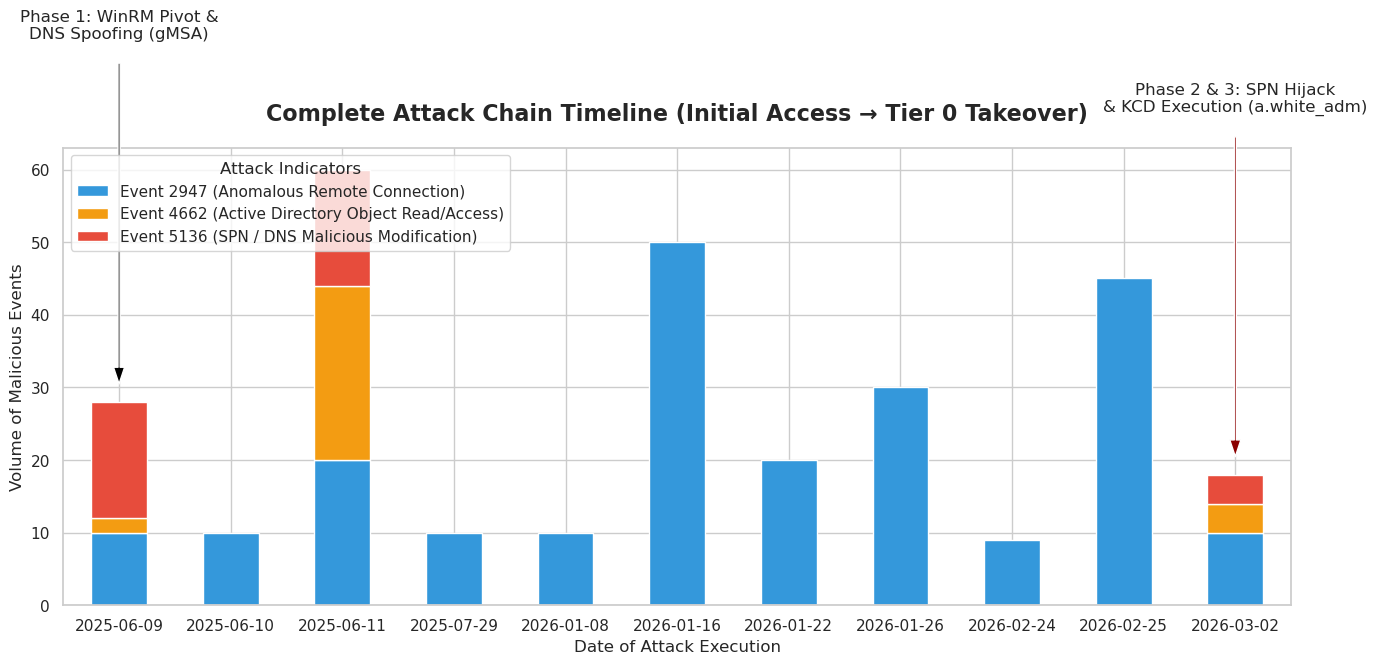

In [42]:
malicious_events = df[
    (df['message'].str.contains('a.white_adm|gMSA_ADFS_prod', na=False, case=False)) & 
    (df['event_id'].isin([5136, 4662, 2947]))
].copy()

## Map the Event IDs to Human-Readable Actions
event_mapping = {
    5136: 'Event 5136 (SPN / DNS Malicious Modification)',
    4662: 'Event 4662 (Active Directory Object Read/Access)',
    2947: 'Event 2947 (Anomalous Remote Connection)'
}
malicious_events['Action_Type'] = malicious_events['event_id'].map(event_mapping)

## Ensure datetime format
malicious_events['datetime'] = pd.to_datetime(malicious_events['datetime'])

## Group by the Day to show the phases of the attack
timeline = malicious_events.groupby([pd.Grouper(key='datetime', freq='D'), 'Action_Type']).size().unstack(fill_value=0)
timeline = timeline[(timeline.T != 0).any()] # Drop empty days

## Plotting the Complete Attack Timeline
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

## Create a stacked bar plot
ax = timeline.plot(kind='bar', stacked=True, color={'Event 5136 (SPN / DNS Malicious Modification)': '#e74c3c', 
                                                    'Event 4662 (Active Directory Object Read/Access)': '#f39c12',
                                                    'Event 2947 (Anomalous Remote Connection)': '#3498db'}, 
                   ax=plt.gca())

plt.title('Complete Attack Chain Timeline (Initial Access → Tier 0 Takeover)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date of Attack Execution', fontsize=12)
plt.ylabel('Volume of Malicious Events', fontsize=12)

## Make x-axis labels readable (Format to Year-Month-Day)
labels = [item.strftime('%Y-%m-%d') for item in timeline.index]
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0, ha='center', fontsize=11)

## Annotate the chart for Management Context
plt.annotate('Phase 1: WinRM Pivot &\nDNS Spoofing (gMSA)', 
             xy=(0, timeline.iloc[0].sum()), xytext=(0, timeline.iloc[0].sum() + 50),
             ha='center', arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8))

plt.annotate('Phase 2 & 3: SPN Hijack\n& KCD Execution (a.white_adm)', 
             xy=(len(timeline)-1, timeline.iloc[-1].sum()), xytext=(len(timeline)-1, timeline.iloc[-1].sum() + 50),
             ha='center', arrowprops=dict(facecolor='darkred', shrink=0.05, width=1.5, headwidth=8))

plt.legend(title='Attack Indicators', loc='upper left')
plt.tight_layout()
plt.show()

## 6. Telemetry Gaps & Strategic Remediation

### The Telemetry Blindspot
While we successfully captured the core SPN and DNS modifications, explicit logs of the NTLM Relays (Event 4624) and the final S4U Ticket Forgeries (Event 4769) were missing. 
* **Cause:** The Domain Controller's Security logs (`Security.evtx`) reached their default capacity limit and "rolled over", overwriting granular network authentication events before forensic acquisition occurred.

### Strategic Recommendations
To prevent this attack path from being utilized in the future, we must enforce the following remediation steps immediately:

1. **Fix the Log Rollover:** Increase the maximum size of `Security.evtx` on all Domain Controllers to at least `1GB` via Group Policy, and implement Windows Event Forwarding (WEF) to stream logs to the SIEM in real-time.
2. **Empty Legacy Groups:** Immediately audit and remove all members (specifically `MS01$`) from the `Pre-Windows 2000 Compatible Access` group.
3. **Enforce LDAP Signing:** Require LDAP Channel Binding and LDAP Signing across all Domain Controllers to neutralize NTLM relay attacks.
4. **Secure SPN Rights:** The `WriteSPN` permission allowed the final KCD hijack. This permission must be strictly audited and removed from all standard user and tier-2 administrator accounts.
5. **Enforce Tiering:** Implement strict Active Directory Tiering to ensure standard users (like `a.white`) do not possess `ForceChangePassword` rights over administrators.